# Experiment 3: Stochastic Training and Temporal Robustness

Evaluates whether training on stochastically corrupted TEMPO data produces
SNNs that generalise to unseen noise levels, compared to training on deterministic
(ideal) Morse timing.

## Training conditions (Exp52 + Exp1 Run 2 recalibrated)

| | Model D (deterministic) | Model S (stochastic) |
|---|---|---|
| **Training σ** | 0 (ideal timing) | 0.575 × T_u (fixed; Exp52 median) |
| **Training r** | 3.0 (fixed) | LogNormal(μ=1.2269, σ=0.2916), median≈3.41 |
| **Training ω** | 1.0 (fixed) | LogNormal(μ=0.036, σ=0.2446), median≈1.04 |
| **T_thresh** | 1.92 × T_u | 1.92 × T_u (Exp1 Run2 re-optimised) |
| **Samples / class** | 500 | 500 |

## Run History

| Run | Architecture | Config | D@σ=0 | S@σ=0 | Crossover |
|-----|-------------|--------|:------:|:------:|:---------:|
| Run 1 (aborted) | Multi-Timescale LIF SNN | BS=1024, BF16, dual-GPU threads | 37.8% | 66.1% | N/A (D failed to converge: 52.9% train acc) |
| Run 2 *(3 seeds)* | Multi-Timescale LIF SNN | BS=256, BF16, dual-GPU threads | 97.9%±0.6 | 98.7%±0.7 | S leads at all σ (confound: stochastic ω/r at all test points puts D OOD) |
| Run 3 *(Exp52 recal.)* | Multi-Timescale LIF SNN | σ=0.575 Tu fixed; LogNormal r/ω; CUDA graphs; checkpoints | 91.1%±1.3 | 92.9%±0.9 | S leads at all σ (stochastic ω/r at test shifts crossover to σ=0) |

---

## Evaluation

Two parallel test sweeps across σ_test ∈ {0.00, 0.20, 0.40, 0.575, 0.80, 1.00, 1.20} × T_u:

| Test condition | ω | r | Purpose |
|---|---|---|---|
| **Main** | LogNormal (stochastic) | LogNormal (stochastic) | Practical deployment: all corruption layers active |
| **Crossover ablation** | 1.0 (fixed) | 3.0 (fixed) | Isolates jitter: D is within its training distribution at σ=0 |

Each test set: 100 samples per class (2,600 total). Main and ablation test sets
use independent RNG seeds to ensure no correlation.  σ* = 0.575 T_u is the
Exp52 calibrated operating point.

## Success Criteria

| Criterion | Target | Rationale |
|-----------|--------|-----------|
| Model D train accuracy | ≥ 90% | Ideal Morse is easy; model should converge cleanly |
| Model S test acc at σ* = 0.575 (main) | ≥ 75% | Matches training noise; consistent with Exp14 at σ=0.45 |
| Crossover exists (ablation) | σ_cross ≤ 1.20 × T_u | With ω/r fixed, D is in-distribution at σ=0; crossover should appear |
| Model S at σ=1.20 | > chance (3.85%) | Graceful degradation beyond training distribution |
| Model D at σ=1.20 | < Model S | D degrades faster than S at extreme noise |

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import threading
import contextlib
from torch.utils.data import DataLoader, TensorDataset

try:
    import snntorch as snn
    from snntorch import surrogate
    print(f'snnTorch {snn.__version__}')
except ImportError:
    print('snnTorch not found.  Install with:  pip install snntorch')
    raise

# Import TEMPO encoder (project root must be on sys.path)
try:
    from tempo.dataset.generate_dataset import encode_word, MORSE_TABLE
except ImportError:
    sys.path.insert(0, os.path.abspath('..'))
    from tempo.dataset.generate_dataset import encode_word, MORSE_TABLE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Default device (overridden by the CUDA setup cell below) ───────────────
FORCE_CPU = False
if FORCE_CPU:
    device = torch.device('cpu')
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device : {device}')
print(f'NumPy  {np.__version__},  PyTorch {torch.__version__},  seed={SEED}')

snnTorch 0.9.4
Device : cuda
NumPy  1.26.3,  PyTorch 2.7.1+cu128,  seed=42


In [2]:
# ── Transmission ─────────────────────────────────────────────────────────────
WPM   = 20
T_U   = 1200.0 / WPM          # 60.0 ms at 20 WPM

# ── TEMPO parameters (jointly calibrated in Experiment 1) ────────────────────
SIGMA           = 0.575        # protocol sigma (fixed) = 0.575 T_u
T_THRESH_FRAC   = 1.92         # channel decision boundary × T_u
T_THRESH        = T_THRESH_FRAC * T_U   # 115.2 ms

# LogNormal parameters for r and omega (MLE fit, Experiment 52, n=36 recordings)
MU_R,     SIGMA_R     = 1.2269, 0.2916   # log-space mean and std of r
MU_OMEGA, SIGMA_OMEGA = 0.0360, 0.2446   # log-space mean and std of omega

MAX_T = 1600                   # fixed tensor length (ms bins)

# ── Protocol reference point for figure annotations ──────────────────────────
SIGMA_STAR = 0.575             # = SIGMA (Model S training noise level)

# ── Dataset ──────────────────────────────────────────────────────────────────
LETTERS   = sorted(k for k in MORSE_TABLE if k.isalpha())
N_CLASSES = len(LETTERS)       # 26
N_TRAIN   = 500                # training samples per class
N_TEST    = 100                # test samples per class per sigma level

# ── Training ─────────────────────────────────────────────────────────────────
N_EPOCHS   = 100
BATCH_SIZE = 256
# Learning rate: 5e-4 → 1e-5 cosine annealing (hard-coded in train_model)

# ── Test sigma sweep ──────────────────────────────────────────────────────────
# Points span 0 → 2.09× the Model S training noise (SIGMA_STAR = 0.575 T_u).
# 0.575 is included explicitly as the protocol operating point.
SIGMA_TEST_FRACS = [0.00, 0.20, 0.40, 0.575, 0.80, 1.00, 1.20]
SIGMA_TEST_ABS   = [f * T_U for f in SIGMA_TEST_FRACS]   # absolute values in ms

# ── Experiment ───────────────────────────────────────────────────────────────
N_SEEDS    = 10
QUICK_RUN  = False     # set True for a fast smoke-test (1 seed, 10 epochs)
if QUICK_RUN:
    N_SEEDS, N_EPOCHS, N_TRAIN, N_TEST = 1, 10, 50, 20

print(f'T_u            = {T_U:.1f} ms')
print(f'sigma          = {SIGMA} T_u = {SIGMA*T_U:.2f} ms  (fixed)')
print(f'T_thresh       = {T_THRESH_FRAC} T_u = {T_THRESH:.2f} ms')
print(f'r              ~ LogNormal(mu={MU_R}, sigma={SIGMA_R})  median={2.718**MU_R:.3f}')
print(f'omega          ~ LogNormal(mu={MU_OMEGA}, sigma={SIGMA_OMEGA})  median={2.718**MU_OMEGA:.3f}')
print(f'sigma_test     : {SIGMA_TEST_FRACS}')
print(f'Letters        : {" ".join(LETTERS)}')
print(f'Train/Test     : {N_TRAIN} / {N_TEST} per class')
print(f'Epochs         : {N_EPOCHS}  (cosine LR: 5e-4 → 1e-5)')
print(f'Batch size     : {BATCH_SIZE}')
print(f'Seeds          : {N_SEEDS}')


T_u            = 60.0 ms
sigma          = 0.575 T_u = 34.50 ms  (fixed)
T_thresh       = 1.92 T_u = 115.20 ms
r              ~ LogNormal(mu=1.2269, sigma=0.2916)  median=3.410
omega          ~ LogNormal(mu=0.036, sigma=0.2446)  median=1.037
sigma_test     : [0.0, 0.2, 0.4, 0.575, 0.8, 1.0, 1.2]
Letters        : A B C D E F G H I J K L M N O P Q R S T U V W X Y Z
Train/Test     : 500 / 100 per class
Epochs         : 100  (cosine LR: 5e-4 → 1e-5)
Batch size     : 256
Seeds          : 10


In [3]:
# ── CUDA environment check ────────────────────────────────────────────────
N_CUDA_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f'CUDA GPUs detected: {N_CUDA_GPUS}')
for i in range(N_CUDA_GPUS):
    props = torch.cuda.get_device_properties(i)
    gb    = props.total_memory / 1024**3
    bf16  = props.major >= 8
    print(f'  cuda:{i}  {props.name}  {gb:.0f} GB  '
          f'cc={props.major}.{props.minor}  BF16={bf16}  SMs={props.multi_processor_count}')

# ── Multi-GPU strategy ───────────────────────────────────────────────────
# With N_CUDA_GPUS workers and 2*N_SEEDS training tasks (N_SEEDS D-models +
# N_SEEDS S-models), all GPUs stay busy: tasks are dispatched from a shared
# queue and each worker grabs any available GPU.  This decouples D and S
# training — they no longer need to be paired on the same two GPUs, allowing
# all N_CUDA_GPUS GPUs to run concurrently.
#
# CUDA graph safety: each GPU is held exclusively by one thread at a time
# (enforced by the _gpool queue), so graph captures on different GPUs are
# independent and safe.  Never dispatch two tasks to the same GPU
# concurrently — the queue mechanism ensures this.
N_GPU_WORKERS = max(N_CUDA_GPUS, 1)

USE_AMP        = N_CUDA_GPUS >= 1 and torch.cuda.get_device_properties(0).major >= 8
USE_CUDA_GRAPH = N_CUDA_GPUS >= 1   # CUDA graphs on L40S; disabled for CPU/MPS
USE_COMPILE    = False               # torch.compile (enable for long production runs)

device_0 = torch.device('cuda:0') if N_CUDA_GPUS >= 1 else torch.device('cpu')
device   = device_0               # keep 'device' alias for backward compat

print()
print(f'N_GPU_WORKERS : {N_GPU_WORKERS}  ({N_CUDA_GPUS} GPUs, task-based pool)')
print(f'USE_AMP       : {USE_AMP}       (BF16 autocast)')
print(f'USE_CUDA_GRAPH: {USE_CUDA_GRAPH}')
print(f'USE_COMPILE   : {USE_COMPILE}')

CUDA GPUs detected: 3
  cuda:0  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142
  cuda:1  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142
  cuda:2  NVIDIA L40S  44 GB  cc=8.9  BF16=True  SMs=142

N_GPU_WORKERS : 3  (3 GPUs, task-based pool)
USE_AMP       : True       (BF16 autocast)
USE_CUDA_GRAPH: True
USE_COMPILE   : False


/home/LukeHindman/.local/lib/python3.9/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## Custom Encoder for Variable Jitter

The TEMPO encoder (`encode_word`) accepts `jitter=True/False` and
hardcodes σ = 0.838 × T_u.  Experiment 3 requires generating test sets
at 7 different σ levels, so we need a local version that accepts σ
as a direct parameter.

`encode_word_sigma` replicates Algorithm 1 (TEMPO v1.1) exactly but:
1. Accepts σ in ms directly (use σ = 0.0 for jitter-free encoding).
2. **Always** samples ω and r stochastically — matching the paper's
   specification that all test conditions use stochastic ω and r.

In [4]:
def encode_letter_hn(letter, t_u, rng, use_noise=True):
    '''Encode a single Morse letter using the Exp52+Exp1r2 recalibrated parameters.

    sigma is the fixed protocol value SIGMA * t_u.
    matching the Experiment 52 slow-tier calibration.
    Channel assignment uses T_THRESH_FRAC * t_u (optimised in Exp1 Run2).

    Returns list of (timestamp_ms, channel) tuples; channel 0=dot, 1=dash.
    '''
    sigma = SIGMA * t_u if use_noise else 0.0
    omega = rng.lognormal(MU_OMEGA, SIGMA_OMEGA) if use_noise else 1.0
    r     = rng.lognormal(MU_R, SIGMA_R) if use_noise else 3.0
    t_thresh = T_THRESH_FRAC * t_u
    min_dur  = 0.1 * t_u

    t_cur  = 0.0
    spikes = []
    for element in MORSE_TABLE[letter]:
        t_ideal  = (1.0 if element == '.' else r) * t_u
        t_noisy  = t_ideal * omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
        t_final  = max(t_noisy, min_dur)
        t_spike  = t_cur + t_final
        channel  = 0 if t_final < t_thresh else 1
        spikes.append((t_spike, channel))
        gap = max(1.0 * t_u * omega + (rng.normal(0, sigma) if sigma > 0 else 0.0), min_dur)
        t_cur = t_spike + gap

    if spikes:
        gap   = max(3.0 * t_u * omega + (rng.normal(0, sigma) if sigma > 0 else 0.0), min_dur)
        t_cur = spikes[-1][0] + gap
    if spikes:
        gap   = max(7.0 * t_u * omega + (rng.normal(0, sigma) if sigma > 0 else 0.0), min_dur)
        t_cur = spikes[-1][0] + gap  # noqa: F841

    return spikes


def encode_word_sigma(word, t_u, sigma, rng=None, omega=None, r=None):
    '''Encode a word with a specific jitter sigma (ms) and configurable omega, r.

    Used for test-set generation where an explicit sigma level is required.
    Channel assignment uses T_THRESH_FRAC (updated from 2.17 to 1.96 in Exp1 Run2).

    Args:
        word:  Uppercase string to encode.
        t_u:   Base time unit (ms).
        sigma: Jitter standard deviation (ms). 0.0 = no Gaussian jitter.
        rng:   numpy RandomGenerator.
        omega: Word-level timing multiplier. If None, sampled from LogNormal(MU_OMEGA, SIGMA_OMEGA).
               Pass a float to fix (e.g. omega=1.0 for the crossover ablation).
        r:     Dash-to-dot duration ratio. If None, sampled from LogNormal(MU_R, SIGMA_R).
               Pass a float to fix (e.g. r=3.0 for the crossover ablation).

    Returns:
        List of (timestamp_ms, channel) tuples; channel 0=dot, 1=dash.
    '''
    if rng is None:
        rng = np.random.default_rng()

    t_thresh  = T_THRESH_FRAC * t_u
    _omega = rng.lognormal(MU_OMEGA, SIGMA_OMEGA) if omega is None else omega
    _r        = rng.lognormal(MU_R, SIGMA_R)    if r     is None else r

    t_current = 0.0
    spikes    = []
    chars     = [c for c in word if c in MORSE_TABLE]

    for ci, char in enumerate(chars):
        pattern = MORSE_TABLE[char]

        for ei, element in enumerate(pattern):
            t_ideal    = (1.0 if element == '.' else _r) * t_u
            t_weighted = t_ideal * _omega
            t_noisy    = t_weighted + rng.normal(0, sigma) if sigma > 0 else t_weighted
            t_final    = max(t_noisy, 0.1 * t_u)

            t_spike = t_current + t_final
            channel = 0 if t_final < t_thresh else 1
            spikes.append((t_spike, channel))

            gap_ideal  = 1.0 * t_u
            gap_noisy  = gap_ideal * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
            gap_final  = max(gap_noisy, 0.1 * t_u)
            t_current  = t_spike + gap_final

        t_current  = spikes[-1][0]
        gap_ideal  = 3.0 * t_u
        gap_noisy  = gap_ideal * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
        gap_final  = max(gap_noisy, 0.1 * t_u)
        t_current += gap_final

    if spikes:
        t_current  = spikes[-1][0]
        gap_ideal  = 7.0 * t_u
        gap_noisy  = gap_ideal * _omega + (rng.normal(0, sigma) if sigma > 0 else 0.0)
        gap_final  = max(gap_noisy, 0.1 * t_u)
        t_current += gap_final

    return spikes


def make_spike_tensor(spikes, max_t):
    '''Convert [(timestamp_ms, channel)] -> binary tensor [max_t, 2].'''
    tensor = np.zeros((max_t, 2), dtype=np.float32)
    for t, ch in spikes:
        idx = int(round(t))
        if 0 <= idx < max_t:
            tensor[idx, ch] = 1.0
    return tensor


# ── Sanity checks ─────────────────────────────────────────────────────────
# encode_letter_hn: verify clean encoding matches expected Morse channels
_rng_t = np.random.default_rng(0)
for _ltr in ['E', 'T', 'A', 'H']:
    _sp = encode_letter_hn(_ltr, T_U, _rng_t, use_noise=False)
    _chs = [c for _, c in _sp]
    print(f'  {_ltr} ({MORSE_TABLE[_ltr]}): {len(_sp)} spikes  channels={_chs}')
print('encode_letter_hn OK')

# encode_word_sigma: fixed omega/r deterministic baseline
_s4 = encode_word_sigma('E', T_U, sigma=0.0, rng=np.random.default_rng(1),
                         omega=1.0, r=3.0)
print(f'E at sigma=0 (fixed omega=1.0, r=3.0): {_s4}')
# T_THRESH_FRAC check: dot at 60 ms < threshold (1.96*60=117.6 ms), dash at 180 ms > threshold
_s5 = encode_word_sigma('A', T_U, sigma=0.0, rng=np.random.default_rng(2),
                         omega=1.0, r=3.0)
print(f'A at sigma=0 (fixed): {_s5}  (expect ch=[0,1])')

  E (.): 1 spikes  channels=[0]
  T (-): 1 spikes  channels=[1]
  A (.-): 2 spikes  channels=[0, 1]
  H (....): 4 spikes  channels=[0, 0, 0, 0]
encode_letter_hn OK
E at sigma=0 (fixed omega=1.0, r=3.0): [(60.0, 0)]
A at sigma=0 (fixed): [(60.0, 0), (300.0, 1)]  (expect ch=[0,1])


## Data Generation

Three data generation functions:

- **`generate_train_split`**: Training data for either model.  
  `deterministic=True` → ideal Morse (σ=0, ω=1.0, r=3.0, Model D);  
  `deterministic=False` → full TEMPO v1.1 (σ=0.838×T_u, ω~U, r~U, Model S).
- **`generate_test_split`**: Main test data at a specified σ level.  
  Always uses stochastic ω and r; only σ varies across the seven test points.
- **`generate_test_split_fixed`**: Crossover ablation test data at a specified σ level.  
  Uses fixed ω=1.0, r=3.0; only σ varies. Places Model D within its training
  distribution at σ_test=0, revealing the clean jitter-training crossover.

Each seed uses independent RNGs for Model D training, Model S training, and each
test set (main and ablation), ensuring no correlation between splits.

In [5]:
def generate_train_split(letters, n_per_class, t_u, max_t, deterministic, rng, label=''):
    '''Generate training data for Model D (deterministic) or Model S (stochastic).

    deterministic=True  -> encode_letter_hn(use_noise=False)
                           sigma=0, omega=1.0, r=3.0 (ideal Morse)
    deterministic=False -> encode_letter_hn(use_noise=True)
                           sigma=SIGMA (fixed), omega~LogNormal, r~LogNormal
                           (Exp52+Exp1r2 recalibrated TEMPO parameters)
    '''
    n_total = len(letters) * n_per_class
    X_list, y_list = [], []
    for label_idx, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_letter_hn(letter, t_u, rng, use_noise=not deterministic)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(label_idx)
        done = (label_idx + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)  # [N, T, 2]
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


def generate_test_split(letters, n_per_class, t_u, max_t, sigma_abs, rng, label=''):
    '''Generate main test data at specified sigma (ms) with stochastic omega and r.

    sigma_abs=0.0 -> no Gaussian jitter, but omega and r are still stochastic.
    Matches the experiment design: all test conditions have stochastic omega/r.
    '''
    n_total = len(letters) * n_per_class
    X_list, y_list = [], []
    for label_idx, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word_sigma(letter, t_u, sigma=sigma_abs, rng=rng)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(label_idx)
        done = (label_idx + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y


def generate_test_split_fixed(letters, n_per_class, t_u, max_t, sigma_abs, rng, label=''):
    '''Generate crossover ablation test data: fixed omega=1.0, r=3.0, varying sigma.

    Holds omega and r at nominal ITU values so that Model D (trained on ideal
    Morse with omega=1.0, r=3.0) is within its training distribution at sigma=0.
    This reveals the clean crossover where stochastic training (Model S) takes
    over from deterministic training (Model D).
    '''
    n_total = len(letters) * n_per_class
    X_list, y_list = [], []
    for label_idx, letter in enumerate(letters):
        for _ in range(n_per_class):
            spikes = encode_word_sigma(letter, t_u, sigma=sigma_abs, rng=rng,
                                       omega=1.0, r=3.0)
            X_list.append(make_spike_tensor(spikes, max_t))
            y_list.append(label_idx)
        done = (label_idx + 1) * n_per_class
        print(f'\r  {label}: {done}/{n_total}', end='', flush=True)
    print()
    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    y = torch.tensor(y_list, dtype=torch.long)
    return X, y

## SNN Architecture — Multi-Timescale LIF SNN (same as Experiment 2)

Both Model D and Model S use the identical TempoSNN architecture validated
in Experiment 2.  The multi-timescale design is important here: Model D's
ideal training data converges easily, while Model S needs the slow group
(τ ≈ 500 ms) to bridge full letter durations under high corruption.

| Group | Neurons | β | τ (ms) | Role |
|-------|--------:|----:|-------:|------|
| Fast  | 42 | 0.95 | ~20 | Local mark detection |
| Medium | 43 | 0.99 | ~100 | Intra-character context |
| Slow  | 43 | 0.998 | ~500 | Full-letter integration |

All groups use soft reset (`reset_mechanism='subtract'`) to preserve
inter-mark membrane state.  All β are learnable.

**Note on training time**: training 6 models (2 × 3 seeds) is approximately
twice the compute of Experiment 2.  Use `QUICK_RUN=True` above for a fast
sanity check before committing to the full run.

In [6]:
spike_grad = surrogate.fast_sigmoid()


class TempoSNN(nn.Module):
    '''Multi-Timescale LIF SNN with soft reset.

    Identical architecture to Experiment 2.  Three neuron groups share
    a single fc1 but use different membrane decay constants, giving the
    network access to fast (~20 ms), medium (~100 ms), and slow (~500 ms)
    temporal scales simultaneously.

    Performance optimization: fc1 and fc2 are batched across all T time
    steps in a single matmul (see Exp2 notebook for details).
    '''

    # (n_neurons, beta, threshold)
    GROUPS = [
        (42,  0.95,  0.3),    # fast:   tau ~  20 ms  -- local mark detection
        (43,  0.99,  0.4),    # medium: tau ~ 100 ms  -- intra-character context
        (43,  0.998, 0.5),    # slow:   tau ~ 500 ms  -- full-letter integration
    ]

    def __init__(self, n_in=2, n_out=26):
        super().__init__()
        n_hid = sum(g[0] for g in self.GROUPS)   # 128
        self.fc1 = nn.Linear(n_in, n_hid)
        # Wide init: ensures neurons fire on first spike (2-channel sparse input)
        nn.init.uniform_(self.fc1.weight, -2.0, 2.0)
        nn.init.zeros_(self.fc1.bias)

        self.lifs = nn.ModuleList([
            snn.Leaky(
                beta=b,
                learn_beta=True,
                threshold=thr,
                reset_mechanism='subtract',
                spike_grad=spike_grad,
            )
            for (_, b, thr) in self.GROUPS
        ])

        self.fc2  = nn.Linear(n_hid, n_out)
        self.lif2 = snn.Leaky(
            beta=0.95,
            learn_beta=True,
            reset_mechanism='subtract',
            spike_grad=spike_grad,
        )
        self._sizes = [g[0] for g in self.GROUPS]

    def forward(self, x):
        # x: [T, B, 2]
        T, B, C = x.shape

        # Batch fc1 across all time steps (single matmul vs 1600 tiny ones)
        cur_all = self.fc1(x.reshape(T * B, C)).reshape(T, B, -1)  # [T, B, n_hid]

        mems    = [lif.init_leaky() for lif in self.lifs]
        spk1_all = []

        for t in range(T):
            cur = cur_all[t]           # [B, n_hid]
            groups, offset = [], 0
            for i, (lif, n) in enumerate(zip(self.lifs, self._sizes)):
                spk_i, mems[i] = lif(cur[:, offset:offset + n], mems[i])
                groups.append(spk_i)
                offset += n
            spk1_all.append(torch.cat(groups, dim=1))   # [B, n_hid]

        # Batch fc2 across all time steps
        spk1_seq = torch.stack(spk1_all, dim=0)          # [T, B, n_hid]
        cur2_all = self.fc2(spk1_seq.reshape(T * B, -1)).reshape(T, B, -1)

        mem2     = self.lif2.init_leaky()
        spk2_acc = None
        for t in range(T):
            spk2, mem2 = self.lif2(cur2_all[t], mem2)
            spk2_acc = spk2 if spk2_acc is None else spk2_acc + spk2

        return spk2_acc   # [B, 26] -- total output spike count


# Verify parameter count (should match Exp2: 3,742)
_demo = TempoSNN()
n_params = sum(p.numel() for p in _demo.parameters())
print(f'Multi-Timescale LIF SNN parameters: {n_params:,}  ({n_params/1e3:.1f}k)')
print()
print('Hidden group configuration:')
for n, b, thr in TempoSNN.GROUPS:
    tau = -1.0 / np.log(b)
    print(f'  beta={b:.3f}  tau~{tau:.0f} ms  threshold={thr}  neurons={n}  learn_beta=True')
print(f'Output: beta=0.95 (init)  tau~{-1/np.log(0.95):.0f} ms  learn_beta=True')

Multi-Timescale LIF SNN parameters: 3,742  (3.7k)

Hidden group configuration:
  beta=0.950  tau~19 ms  threshold=0.3  neurons=42  learn_beta=True
  beta=0.990  tau~99 ms  threshold=0.4  neurons=43  learn_beta=True
  beta=0.998  tau~499 ms  threshold=0.5  neurons=43  learn_beta=True
Output: beta=0.95 (init)  tau~19 ms  learn_beta=True


## Training and Evaluation Functions

Training uses the same hyperparameters as Experiment 2:
Adam optimizer, lr = 5×10⁻⁴ with cosine annealing to η_min = 10⁻⁵,
100 epochs, gradient clipping (max_norm = 1.0).

### CUDA optimizations (applied automatically)

| Optimization | Mechanism | Expected gain |
|---|---|---|
| **BF16 autocast** | `torch.autocast('cuda', bfloat16)` | ~2× matmul throughput on L40S tensor cores |
| **Pinned memory** | `DataLoader(pin_memory=True)` | Faster CPU→GPU transfer, overlaps with compute |
| **Non-blocking transfers** | `.to(device, non_blocking=True)` | H→D copy runs while GPU executes previous batch |
| **4 DataLoader workers** | `num_workers=4` | Prefetches next batch while GPU trains on current |
| **torch.compile** | `torch.compile(mode='max-autotune')` | Fuses per-step LIF element-wise ops; ~15–25% extra |

All optimizations degrade gracefully to no-ops on CPU/MPS — the same code
runs unchanged on the MacBook.

### Thread safety for parallel GPU training

`train_model` uses `_init_lock` (a module-level `threading.Lock`) to
serialise the `torch.manual_seed()` + weight init section.  The global
CPU RNG state is shared across threads, so concurrent calls to
`torch.manual_seed()` would produce non-deterministic initialisation.
The lock ensures each model is seeded and initialised atomically before
the training loop (which is fully thread-safe) begins.  Print output
from parallel threads is serialised by `_print_lock`.

In [7]:
# Thread-safety locks (module-level, shared across all threads)
_init_lock       = threading.Lock()   # serialises torch.manual_seed + weight init
_cuda_graph_lock = threading.Lock()   # serialises CUDA graph capture (global state)
_print_lock      = threading.Lock()   # serialises print output from parallel workers


# ── CUDA Graph step builder ───────────────────────────────────────────────
def build_cuda_graph_step(model, batch_size, max_t, device, use_amp):
    '''Capture forward+loss+backward as a single replayable CUDA graph.

    Eliminates ~10,000 Python-dispatched kernel launches per batch for the
    1600-timestep SNN forward pass.  Constraints (SNN_CUDA_Training_Reference):
    - Static input buffers: graph records addresses; .copy_() swaps content.
    - set_to_none=False: preserves .grad addresses the graph writes into.
    - 3 warmup runs: allocate gradient tensors at stable GPU addresses.
    - _cuda_graph_lock: only one capture at a time globally.
    - capture_error_mode='thread_local': surfaces errors per-thread.
    '''
    amp_ctx = (torch.autocast('cuda', dtype=torch.bfloat16)
               if use_amp else contextlib.nullcontext())

    with _cuda_graph_lock:
        s           = torch.cuda.Stream(device=device)
        static_x    = torch.zeros(max_t, batch_size, 2, device=device)
        static_y    = torch.zeros(batch_size, dtype=torch.long, device=device)
        static_loss = torch.zeros((), device=device)

        s.wait_stream(torch.cuda.current_stream(device))
        with torch.cuda.stream(s):
            for _ in range(3):
                model.zero_grad(set_to_none=False)
                with amp_ctx:
                    out  = model(static_x)
                    loss = F.cross_entropy(out.float(), static_y)
                loss.backward()
        torch.cuda.current_stream(device).wait_stream(s)
        model.zero_grad(set_to_none=False)

        g = torch.cuda.CUDAGraph()
        with torch.cuda.graph(g, stream=s, capture_error_mode='thread_local'):
            with amp_ctx:
                static_out      = model(static_x)
                static_loss_val = F.cross_entropy(static_out.float(), static_y)
            static_loss_val.backward()
            static_loss.copy_(static_loss_val)

    return g, static_x, static_y, static_loss, static_out


def train_epoch_graph(model, X_gpu, y_gpu, batch_size, optimizer, device, graph_state):
    '''One training epoch using CUDA graph replay.'''
    model.train()
    g, static_x, static_y, static_loss, static_out = graph_state
    N    = X_gpu.size(0)
    perm = torch.randperm(N).to(device)   # CPU randperm avoids advancing CUDA RNG
    total_loss = correct = total = 0
    for bi in range(0, N - batch_size + 1, batch_size):
        idx = perm[bi:bi + batch_size]
        static_x.copy_(X_gpu[idx].permute(1, 0, 2))  # [B,T,2] -> [T,B,2]
        static_y.copy_(y_gpu[idx])
        optimizer.zero_grad(set_to_none=False)
        g.replay()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += static_loss.item() * batch_size
        correct    += (static_out.detach().float().argmax(1) == y_gpu[idx]).sum().item()
        total      += batch_size
    return total_loss / total, correct / total


def train_epoch_plain(model, X_gpu, y_gpu, batch_size, optimizer, device, use_amp):
    '''Standard (non-graph) training epoch — fallback for CPU/MPS.'''
    model.train()
    amp_ctx = (torch.autocast('cuda', dtype=torch.bfloat16)
               if use_amp else contextlib.nullcontext())
    N    = X_gpu.size(0)
    perm = torch.randperm(N)
    total_loss = correct = total = 0
    for bi in range(0, N - batch_size + 1, batch_size):
        idx = perm[bi:bi + batch_size].to(device)
        xb  = X_gpu[idx].permute(1, 0, 2)   # [T, B, 2]
        yb  = y_gpu[idx]
        optimizer.zero_grad(set_to_none=False)
        with amp_ctx:
            out  = model(xb)
            loss = F.cross_entropy(out.float(), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.detach().float().item() * batch_size
        correct    += (out.detach().float().argmax(1) == yb).sum().item()
        total      += batch_size
    return total_loss / total, correct / total


def train_model(X_train, y_train, n_epochs, batch_size, device, seed,
                label='', use_amp=False, use_graph=False):
    '''Train a fresh TempoSNN on pre-loaded GPU tensors.

    X_train, y_train must already be on `device`.
    Uses CUDA graph replay when use_graph=True (requires CUDA).
    Thread-safe: _init_lock serialises torch.manual_seed + TempoSNN.__init__.
    '''
    with _init_lock:
        torch.manual_seed(seed)
        model     = TempoSNN().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-5
    )

    if use_graph and device.type == 'cuda':
        graph_state = build_cuda_graph_step(
            model, batch_size, MAX_T, device, use_amp)
        def run_epoch():
            return train_epoch_graph(
                model, X_train, y_train, batch_size, optimizer, device, graph_state)
    else:
        def run_epoch():
            return train_epoch_plain(
                model, X_train, y_train, batch_size, optimizer, device, use_amp)

    losses, accs = [], []
    for epoch in range(n_epochs):
        loss, acc = run_epoch()
        scheduler.step()
        losses.append(loss)
        accs.append(acc)
        if (epoch + 1) % 10 == 0:
            with _print_lock:
                print(f'  [{label}] Epoch {epoch+1:3d}/{n_epochs}  '
                      f'loss={loss:.4f}  acc={acc*100:.1f}%  '
                      f'lr={scheduler.get_last_lr()[0]:.2e}')

    return model, losses, accs


def evaluate(model, X, y, device):
    '''Evaluate model accuracy on CPU tensors (X, y); batches moved to device internally.'''
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for bi in range(0, len(X), 512):
            xb = X[bi:bi+512].permute(1, 0, 2).to(device, non_blocking=True)
            yb = y[bi:bi+512].to(device, non_blocking=True)
            out = model(xb)
            correct += (out.float().argmax(1) == yb).sum().item()
            total   += len(yb)
    return correct / total


print('Training infrastructure with CUDA graphs defined.')
print(f'USE_AMP={USE_AMP}  USE_CUDA_GRAPH={USE_CUDA_GRAPH}')

Training infrastructure with CUDA graphs defined.
USE_AMP=True  USE_CUDA_GRAPH=True


## Main Experiment

For each seed:
1. Generate training data for Model D (σ=0, ω=1.0, r=3.0 — deterministic ideal Morse) and Model S (full TEMPO v1.1).
2. Train both models with identical hyperparameters and architecture.
3. Generate two fresh test sets at each of the 7 σ_test levels:
   - **Main test**: stochastic ω~U[0.8,1.3] and r~U[2.5,4.5] (used for both models; same test set per seed)
   - **Crossover ablation**: fixed ω=1.0, r=3.0 — isolates Gaussian jitter contribution
4. Evaluate both models on each test set.

RNG strategy:
- Model D training data:  (base seed; ideal Morse, sigma=0, omega=1.0, r=3.0)
- Model S training data:  (offset to avoid correlation; full TEMPO v1.1)
- Model D torch seed: 
- Model S torch seed: 
- Test set at σ_frac (main):     
- Test set at σ_frac (ablation): 


In [8]:
import queue as _q
import concurrent.futures

# ── Checkpoint directory ──────────────────────────────────────────────────
CKPT_DIR = os.path.join('..', 'checkpoints', 'exp3')
os.makedirs(CKPT_DIR, exist_ok=True)

# ── GPU pool: N_GPU_WORKERS slots, one per GPU ────────────────────────────
_gpool = _q.Queue()
for _i in range(N_GPU_WORKERS):
    _gpool.put(_i)


def _train_task(model_type, seed):
    '''Train one model (D or S) on any available GPU, with checkpoint save/load.'''
    gpu_id = _gpool.get()
    dev    = torch.device(f'cuda:{gpu_id}') if N_CUDA_GPUS > 0 else device_0
    try:
        deterministic = (model_type == 'D')
        rng_seed      = seed if deterministic else seed + 1000
        rng           = np.random.default_rng(rng_seed)
        torch_seed    = seed * 2 if deterministic else seed * 2 + 1

        ckpt_path = os.path.join(CKPT_DIR, f'exp3_{model_type}_seed{seed}.pt')

        if os.path.exists(ckpt_path):
            with _print_lock:
                print(f'  [{model_type}] seed={seed}: loading {ckpt_path}')
            with _init_lock:
                model = TempoSNN()
            raw = torch.load(ckpt_path, map_location='cpu', weights_only=True)
            if isinstance(raw, dict) and 'state_dict' in raw:
                # New format: includes final_train_acc
                model.load_state_dict(raw['state_dict'])
                train_accs = [raw.get('final_train_acc', float('nan'))]
            else:
                # Legacy format: raw is the OrderedDict state_dict
                model.load_state_dict(raw)
                train_accs = []
            model = model.to(dev)
            losses = []
        else:
            X, y = generate_train_split(
                LETTERS, N_TRAIN, T_U, MAX_T,
                deterministic=deterministic, rng=rng,
                label=f'{model_type}(seed={seed})',
            )
            X_gpu = X.to(dev, non_blocking=True)
            y_gpu = y.to(dev, non_blocking=True)
            if dev.type == 'cuda':
                torch.cuda.synchronize(dev)
                with _print_lock:
                    print(f'  [{model_type}] seed={seed} gpu={gpu_id}: '
                          f'{torch.cuda.memory_allocated(dev)//1024//1024} MB')

            model, losses, train_accs = train_model(
                X_gpu, y_gpu, N_EPOCHS, BATCH_SIZE, dev, seed=torch_seed,
                label=f'{model_type}(s={seed},gpu={gpu_id})',
                use_amp=USE_AMP, use_graph=USE_CUDA_GRAPH,
            )

            del X_gpu, y_gpu, X, y
            if dev.type == 'cuda':
                torch.cuda.empty_cache()
            # Save state_dict + final training accuracy so future loads have it
            torch.save({
                'state_dict':      model.state_dict(),
                'final_train_acc': float(train_accs[-1]),
            }, ckpt_path)
            with _print_lock:
                print(f'  [{model_type}] seed={seed}: saved -> {ckpt_path}')

        final_acc = train_accs[-1] if train_accs else float('nan')
        with _print_lock:
            acc_str = f'{final_acc*100:.1f}%' if not np.isnan(final_acc) else 'ckpt (legacy)'
            print(f'  [{model_type}] seed={seed} gpu={gpu_id}: train_acc={acc_str}')

        return {
            'type': model_type, 'seed': seed,
            'model': model, 'losses': losses, 'accs': train_accs, 'device': dev,
        }
    finally:
        _gpool.put(gpu_id)


# ── Dispatch all training tasks to the GPU pool ───────────────────────────
tasks = [
    (mt, SEED + si)
    for si in range(N_SEEDS)
    for mt in ['D', 'S']
]

print(f'Training {len(tasks)} models ({N_SEEDS} D + {N_SEEDS} S) '
      f'across {N_GPU_WORKERS} GPU workers...\n')

trained = {}   # (model_type, seed) -> result dict

with concurrent.futures.ThreadPoolExecutor(max_workers=N_GPU_WORKERS) as executor:
    futures = {
        executor.submit(_train_task, mt, seed): (mt, seed)
        for mt, seed in tasks
    }
    for fut in concurrent.futures.as_completed(futures):
        res = fut.result()
        trained[(res['type'], res['seed'])] = res

# ── Main evaluation: stochastic omega and r at all sigma levels ───────────
print('\nMain evaluation (stochastic omega, r)...')
all_results = []

for seed_idx in range(N_SEEDS):
    seed  = SEED + seed_idx
    res_D = trained[('D', seed)]
    res_S = trained[('S', seed)]
    model_D, dev_D = res_D['model'], res_D['device']
    model_S, dev_S = res_S['model'], res_S['device']

    print(f'\n  --- Seed {seed_idx+1}/{N_SEEDS}  (seed={seed}) ---')
    result_D, result_S = {}, {}

    for sigma_frac, sigma_abs in zip(SIGMA_TEST_FRACS, SIGMA_TEST_ABS):
        rng_test = np.random.default_rng(seed * 100_000 + int(round(sigma_frac * 1000)))
        X_test, y_test = generate_test_split(
            LETTERS, N_TEST, T_U, MAX_T, sigma_abs, rng_test,
            label=f'Test(sigma={sigma_frac:.2f})',
        )
        acc_D = evaluate(model_D, X_test, y_test, dev_D)
        acc_S = evaluate(model_S, X_test, y_test, dev_S)
        result_D[sigma_frac] = acc_D
        result_S[sigma_frac] = acc_S
        print(f'    sigma={sigma_frac:.2f}*T_u: D={acc_D*100:.1f}%  S={acc_S*100:.1f}%')

    all_results.append({
        'seed':        seed,
        'D':           result_D,
        'S':           result_S,
        'D_losses':    res_D['losses'],
        'S_losses':    res_S['losses'],
        # Guard against empty accs when model was loaded from legacy checkpoint
        'D_train_acc': res_D['accs'][-1] if res_D['accs'] else float('nan'),
        'S_train_acc': res_S['accs'][-1] if res_S['accs'] else float('nan'),
    })

print('\nMain evaluation complete.')

# ── Crossover ablation: fixed omega=1.0, r=3.0 ───────────────────────────
# RNG seeds offset by +500_000 from main test seeds to ensure independence.
print('\nCrossover ablation (fixed omega=1.0, r=3.0)...')
all_results_fixed = []

for seed_idx in range(N_SEEDS):
    seed  = SEED + seed_idx
    res_D = trained[('D', seed)]
    res_S = trained[('S', seed)]
    model_D, dev_D = res_D['model'], res_D['device']
    model_S, dev_S = res_S['model'], res_S['device']

    print(f'\n  --- Seed {seed_idx+1}/{N_SEEDS}  (seed={seed}) ---')
    result_D, result_S = {}, {}

    for sigma_frac, sigma_abs in zip(SIGMA_TEST_FRACS, SIGMA_TEST_ABS):
        rng_test = np.random.default_rng(
            seed * 100_000 + int(round(sigma_frac * 1000)) + 500_000)
        X_test, y_test = generate_test_split_fixed(
            LETTERS, N_TEST, T_U, MAX_T, sigma_abs, rng_test,
            label=f'FixedTest(sigma={sigma_frac:.2f})',
        )
        acc_D = evaluate(model_D, X_test, y_test, dev_D)
        acc_S = evaluate(model_S, X_test, y_test, dev_S)
        result_D[sigma_frac] = acc_D
        result_S[sigma_frac] = acc_S
        print(f'    sigma={sigma_frac:.2f}*T_u: D={acc_D*100:.1f}%  S={acc_S*100:.1f}%')

    all_results_fixed.append({
        'seed':  seed,
        'D':     result_D,
        'S':     result_S,
    })

print('\nCrossover ablation complete.')

Training 20 models (10 D + 10 S) across 3 GPU workers...

  [D] seed=42: loading ../checkpoints/exp3/exp3_D_seed42.pt
  [S] seed=42: loading ../checkpoints/exp3/exp3_S_seed42.pt
  [D] seed=43: loading ../checkpoints/exp3/exp3_D_seed43.pt


  [D] seed=42 gpu=0: train_acc=ckpt (legacy)
  [D] seed=43 gpu=2: train_acc=ckpt (legacy)
  [S] seed=42 gpu=1: train_acc=ckpt (legacy)
  [D] seed=44: loading ../checkpoints/exp3/exp3_D_seed44.pt
  [S] seed=43: loading ../checkpoints/exp3/exp3_S_seed43.pt
  [S] seed=44: loading ../checkpoints/exp3/exp3_S_seed44.pt
  [D] seed=44 gpu=2: train_acc=ckpt (legacy)
  [S] seed=43 gpu=0: train_acc=ckpt (legacy)
  [S] seed=44 gpu=1: train_acc=ckpt (legacy)
  [D] seed=45: loading ../checkpoints/exp3/exp3_D_seed45.pt
  [S] seed=45: loading ../checkpoints/exp3/exp3_S_seed45.pt
  [D] seed=46: loading ../checkpoints/exp3/exp3_D_seed46.pt
  [D] seed=45 gpu=2: train_acc=ckpt (legacy)
  [S] seed=46: loading ../checkpoints/exp3/exp3_S_seed46.pt
  [S] seed=45 gpu=0: train_acc=ckpt (legacy)
  [D] seed=46 gpu=1: train_acc=ckpt (legacy)
  [D] seed=47: loading ../checkpoints/exp3/exp3_D_seed47.pt
  [S] seed=47: loading ../checkpoints/exp3/exp3_S_seed47.pt
  [S] seed=46 gpu=2: train_acc=ckpt (legacy)
  [D] seed

  Test(sigma=0.00): 200/2600

  Test(sigma=0.00): 300/2600

  Test(sigma=0.00): 400/2600

...

  FixedTest(sigma=1.20): 2300/2600

  FixedTest(sigma=1.20): 2400/2600

  FixedTest(sigma=1.20): 2500/2600

  FixedTest(sigma=1.20): 2600/2600

    sigma=1.20*T_u: D=50.7%  S=50.9%

Crossover ablation complete.


In [9]:
import math

# ── Statistical utilities (no scipy dependency) ───────────────────────────
def _betacf(x, a, b, maxit=200, eps=3e-7):
    tiny = 1e-30
    qab, qap, qam = a + b, a + 1.0, a - 1.0
    c, d = 1.0, 1.0 - qab * x / qap
    if abs(d) < tiny: d = tiny
    d, h = 1.0 / d, 1.0 / d
    for m in range(1, maxit + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d = 1.0 / d;  h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d;  d = tiny if abs(d) < tiny else d
        c = 1.0 + aa / c;  c = tiny if abs(c) < tiny else c
        d = 1.0 / d;  delta = d * c;  h *= delta
        if abs(delta - 1.0) < eps: break
    return h

def _ibeta(x, a, b):
    if x <= 0.0: return 0.0
    if x >= 1.0: return 1.0
    lb = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    bt = math.exp(a * math.log(x) + b * math.log(1 - x) - lb)
    if x < (a + 1) / (a + b + 2):
        return bt * _betacf(x, a, b) / a
    return 1.0 - bt * _betacf(1 - x, b, a) / b

def t_sf(t, df):
    """One-tailed P(T > t) for Student's t."""
    if t < 0: return 1.0 - t_sf(-t, df)
    return _ibeta(df / (df + t * t), df / 2.0, 0.5) / 2.0

def paired_t_test(a, b):
    """One-tailed paired t-test H₁: mean(a) > mean(b)."""
    n = len(a)
    d = [x - y for x, y in zip(a, b)]
    mu = sum(d) / n
    sd = math.sqrt(sum((x - mu)**2 for x in d) / (n - 1))
    se = sd / math.sqrt(n)
    t  = mu / se if se > 1e-12 else float('inf')
    return mu, sd, t, t_sf(t, df=n - 1)


def print_analysis(results, label):
    n_seeds = len(results)
    print(f'\n{"=" * 60}')
    print(f'{label}  (mean ± std, n={n_seeds} seeds)')
    print(f'{"=" * 60}')
    print(f'{"sigma/T_u":>10}  {"Model D":>12}  {"Model S":>12}  {"Δ(S-D)":>9}')
    print('-' * 50)
    rows = []
    for sigma in SIGMA_TEST_FRACS:
        d_vals = [r['D'][sigma] * 100 for r in results]
        s_vals = [r['S'][sigma] * 100 for r in results]
        d_mean = sum(d_vals) / n_seeds
        s_mean = sum(s_vals) / n_seeds
        d_std  = math.sqrt(sum((x - d_mean)**2 for x in d_vals) / (n_seeds - 1))
        s_std  = math.sqrt(sum((x - s_mean)**2 for x in s_vals) / (n_seeds - 1))
        delta  = s_mean - d_mean
        lead   = 'S>' if delta > 0 else 'D>'
        print(f'{sigma:>10.2f}  {d_mean:>5.1f}±{d_std:.1f}%  '
              f'{s_mean:>5.1f}±{s_std:.1f}%  {delta:>+8.2f}pp  {lead}')
        rows.append((sigma, d_vals, s_vals))

    # Crossover detection
    for sigma, d_vals, s_vals in rows:
        if sum(s_vals) / n_seeds >= sum(d_vals) / n_seeds:
            print(f'\n  First crossover (S ≥ D): sigma_test = {sigma:.2f} × T_u')
            break
    else:
        print('\n  No crossover detected (D leads throughout)')

    # Paired t-tests
    df_t = n_seeds - 1
    print(f'\nPaired t-tests (one-tailed H₁: S > D, df={df_t}):')
    print(f'{"sigma/T_u":>10}  {"mean Δ":>8}  {"std Δ":>7}  {"t":>7}  {"p":>8}  sig')
    print('-' * 55)
    sig_count = 0
    for sigma, d_vals, s_vals in rows:
        mu, sd, t, p = paired_t_test(s_vals, d_vals)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        if p < 0.05: sig_count += 1
        print(f'{sigma:>10.2f}  {mu:>+8.2f}  {sd:>7.3f}  {t:>7.3f}  {p:>8.4f}  {sig}')

    n_levels = len(SIGMA_TEST_FRACS)
    all_pos = all(
        sum(r['S'][s] > r['D'][s] for r in results) > n_seeds / 2
        for s in SIGMA_TEST_FRACS
    )
    p_sign = 0.5 ** n_levels
    print(f'\nSignificant at p<0.05: {sig_count}/{n_levels} noise levels')
    print(f'Sign test (S>D at all {n_levels} levels): '
          f'{"YES" if all_pos else "NO"}  p = {p_sign:.4f}'
          f'{"  **" if p_sign < 0.01 else ""}')


# ── Run analysis for both result sets ────────────────────────────────────
print_analysis(all_results,       'Main test  (stochastic ω, r)')
print_analysis(all_results_fixed, 'Crossover ablation  (fixed ω=1.0, r=3.0)')

# ── R2.10c Verification ────────────────────────────────────────────────
# Confirm Model D achieves 100.0% ± 0.0% at sigma_test=0 in the crossover
# ablation (fixed omega=1.0, r=3.0), confirming the table footnote.
_d_abl_zero = [r['D'][0.0] * 100 for r in all_results_fixed]
if _d_abl_zero:
    _m, _s = np.mean(_d_abl_zero), np.std(_d_abl_zero)
    _status = 'CONFIRMED' if (_m == 100.0 and _s == 0.0) else 'CHECK MANUALLY'
    print(f'R2.10c — Model D at σ=0 (ablation, {len(_d_abl_zero)} seeds): '
          f'{_m:.1f}% ± {_s:.1f}%  [{_status}]')



Main test  (stochastic ω, r)  (mean ± std, n=10 seeds)
 sigma/T_u       Model D       Model S     Δ(S-D)
--------------------------------------------------
      0.00   91.1±1.3%   92.9±0.9%     +1.78pp  S>
      0.20   88.7±1.4%   90.6±0.7%     +1.83pp  S>
      0.40   82.4±1.3%   84.3±0.7%     +1.87pp  S>
      0.57   73.8±0.8%   75.7±0.8%     +1.92pp  S>
      0.80   62.8±1.2%   65.0±0.8%     +2.25pp  S>
      1.00   55.1±1.4%   57.4±0.9%     +2.33pp  S>
      1.20   49.0±1.7%   51.6±1.1%     +2.61pp  S>

  First crossover (S ≥ D): sigma_test = 0.00 × T_u

Paired t-tests (one-tailed H₁: S > D, df=9):
 sigma/T_u    mean Δ    std Δ        t         p  sig
-------------------------------------------------------
      0.00     +1.78    1.520    3.697    0.0025  **
      0.20     +1.83    1.565    3.700    0.0025  **
      0.40     +1.87    1.379    4.277    0.0010  **
      0.57     +1.92    1.088    5.578    0.0002  ***
      0.80     +2.25    0.993    7.166    0.0000  ***
      1.00 

## Figure: Stochastic Training and Temporal Robustness

Two panels:
- **Left** — mean ± std accuracy for Models D and S as a function of
  test noise level σ_test / T_u.  Reference lines mark chance (3.85%),
  Model S training noise (0.838), and the detected crossover point.
- **Right** — per-seed accuracy curves for both models, showing
  seed-to-seed variability.

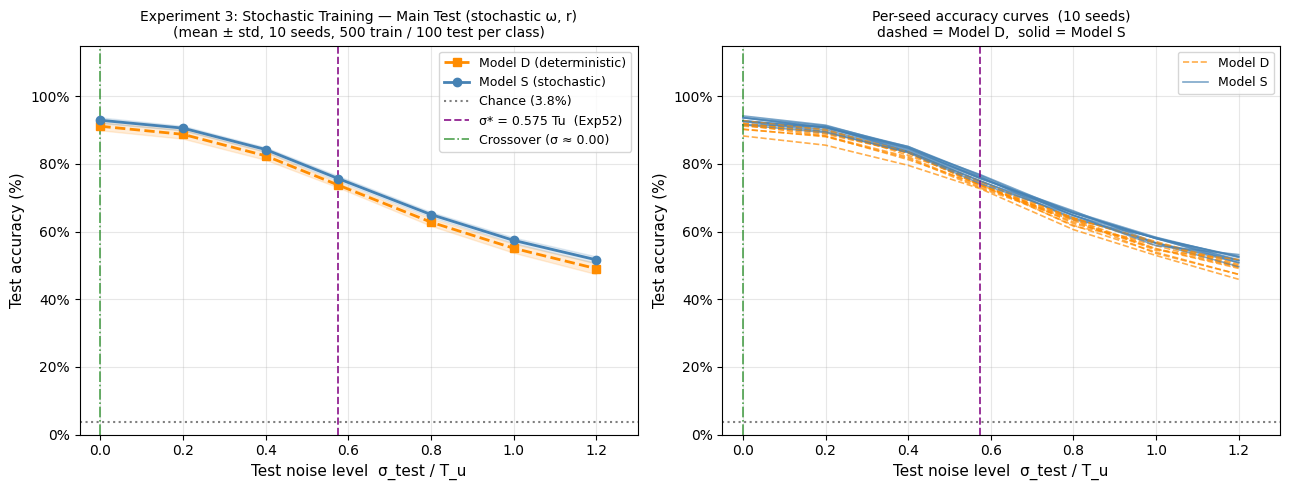

Saved -> ../figures/exp3_stochastic_robustness.pdf


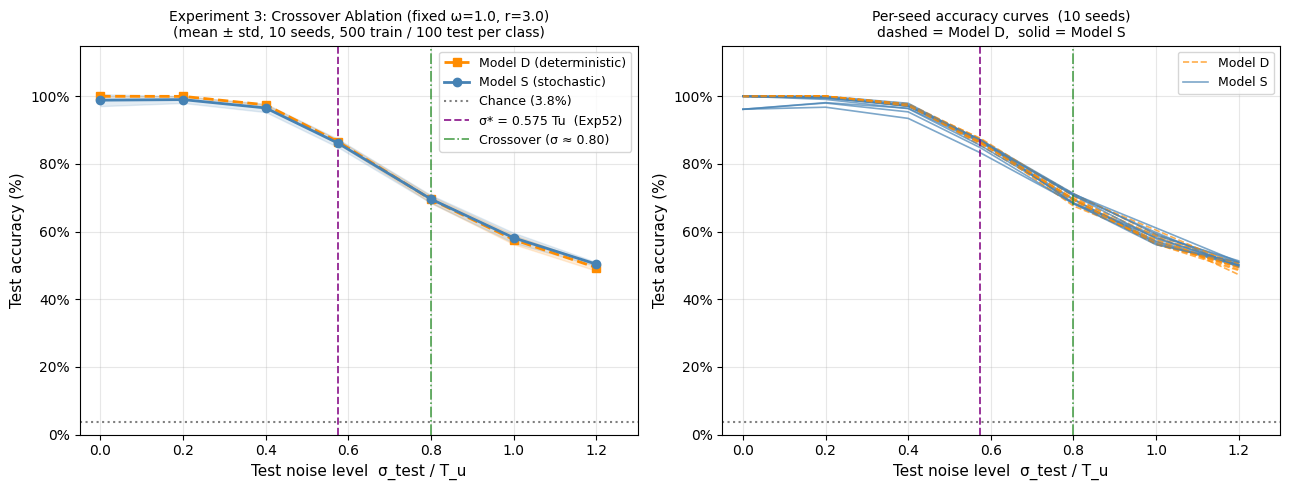

Saved -> ../figures/exp3_crossover_ablation.pdf


In [10]:
import matplotlib.ticker as mticker

sigma_x = np.array(SIGMA_TEST_FRACS)
chance  = 100.0 / N_CLASSES   # 3.85%


def make_figure(results, title_main, fname, lstm_data=None):
    """Produce a 2-panel robustness figure for one result set.

    lstm_data: optional (means_array, stds_array) both shape [n_sigma],
               adds LSTM as a third line in the left (summary) panel only.
               Crossover ablation figure should call this with lstm_data=None.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left panel: mean ± std ────────────────────────────────────────────
    ax = axes[0]
    for model_key, label, color, ls, mkr in [
        ('D', 'Model D (deterministic)', 'darkorange', '--', 's'),
        ('S', 'Model S (stochastic)',    'steelblue',  '-',  'o'),
    ]:
        means = np.array([
            np.mean([r[model_key][sf] * 100 for r in results])
            for sf in SIGMA_TEST_FRACS
        ])
        stds = np.array([
            np.std([r[model_key][sf] * 100 for r in results])
            for sf in SIGMA_TEST_FRACS
        ])
        ax.plot(sigma_x, means, ls=ls, color=color, lw=2.0,
                marker=mkr, ms=6, label=label, zorder=4)
        ax.fill_between(sigma_x, means - stds, means + stds,
                        color=color, alpha=0.15, zorder=3)

    # Optional LSTM baseline line (left panel only)
    if lstm_data is not None:
        lstm_means_plt, lstm_stds_plt = lstm_data
        ax.plot(sigma_x, lstm_means_plt, ls=':', color='crimson', lw=2.0,
                marker='x', ms=7, markeredgewidth=2,
                label=f'LSTM baseline (~{n_lstm_params:,} params)', zorder=4)
        ax.fill_between(sigma_x,
                        lstm_means_plt - lstm_stds_plt,
                        lstm_means_plt + lstm_stds_plt,
                        color='crimson', alpha=0.12, zorder=3)

    ax.axhline(chance, ls=':', color='gray', lw=1.5,
               label=f'Chance ({chance:.1f}%)', zorder=2)
    ax.axvline(SIGMA_STAR, ls='--', color='purple', lw=1.4, alpha=0.8,
               label=f'σ* = {SIGMA_STAR} Tu  (Exp52)', zorder=2)

    _means_D = np.array([np.mean([r['D'][sf] * 100 for r in results])
                         for sf in SIGMA_TEST_FRACS])
    _means_S = np.array([np.mean([r['S'][sf] * 100 for r in results])
                         for sf in SIGMA_TEST_FRACS])
    _cx_mask = _means_S >= _means_D
    if _cx_mask.any():
        _cx_frac = float(sigma_x[int(np.where(_cx_mask)[0][0])])
        ax.axvline(_cx_frac, ls='-.', color='forestgreen', lw=1.2, alpha=0.8,
                   label=f'Crossover (σ ≈ {_cx_frac:.2f})', zorder=2)

    ax.set_xlabel('Test noise level  σ_test / T_u', fontsize=11)
    ax.set_ylabel('Test accuracy (%)', fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_xlim(-0.05, 1.30)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_title(
        f'{title_main}\n'
        f'(mean ± std, {N_SEEDS} seeds, {N_TRAIN} train / {N_TEST} test per class)',
        fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, zorder=0)

    # ── Right panel: per-seed curves (D vs S only) ────────────────────────
    ax = axes[1]
    for si, result in enumerate(results):
        accs_D = [result['D'][sf] * 100 for sf in SIGMA_TEST_FRACS]
        accs_S = [result['S'][sf] * 100 for sf in SIGMA_TEST_FRACS]
        ax.plot(sigma_x, accs_D, '--', color='darkorange', lw=1.2, alpha=0.7,
                label='Model D' if si == 0 else '_')
        ax.plot(sigma_x, accs_S, '-',  color='steelblue',  lw=1.2, alpha=0.7,
                label='Model S' if si == 0 else '_')

    ax.axhline(chance, ls=':', color='gray', lw=1.5)
    ax.axvline(SIGMA_STAR, ls='--', color='purple', lw=1.4, alpha=0.8)
    if _cx_mask.any():
        ax.axvline(_cx_frac, ls='-.', color='forestgreen', lw=1.2, alpha=0.8)

    ax.set_xlabel('Test noise level  σ_test / T_u', fontsize=11)
    ax.set_ylabel('Test accuracy (%)', fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_xlim(-0.05, 1.30)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_title(
        f'Per-seed accuracy curves  ({N_SEEDS} seeds)\n'
        'dashed = Model D,  solid = Model S',
        fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, zorder=0)

    fig.tight_layout()
    fig.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {fname}')


make_figure(
    all_results,
    'Experiment 3: Stochastic Training — Main Test (stochastic ω, r)',
    '../figures/exp3_stochastic_robustness.pdf',
)

make_figure(
    all_results_fixed,
    'Experiment 3: Crossover Ablation (fixed ω=1.0, r=3.0)',
    '../figures/exp3_crossover_ablation.pdf',
)

## LSTM Baseline (R1.3 / R2.1)

A parameter-matched LSTM (~3,822 parameters) trained on the same
stochastic TEMPO data as Model~S and evaluated on the same noise sweep.
This directly tests whether the SNN's temporal robustness is SNN-specific
or achievable by any sequence model.

In [11]:
import torch.nn as nn

# ── LSTM architecture (parameter-matched to SNN ~3,741 params) ────────────
class TempoLSTM(nn.Module):
    """
    Single-layer LSTM baseline for TEMPO Experiment 3.
    input_size=2 (dot/dash channels), hidden_size=26.
    Readout: max-pool hidden state over T → Linear(26, 26).
    Parameter count: ~3,822 (≈ SNN 3,741).
    """
    HIDDEN = 26

    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=self.HIDDEN, batch_first=False)
        self.fc   = nn.Linear(self.HIDDEN, N_CLASSES)

    def forward(self, x):
        # x: [T, B, 2]  (time-first, matching SNN input format)
        out, _ = self.lstm(x)          # [T, B, HIDDEN]
        pooled = out.max(dim=0).values # [B, HIDDEN]  — analogous to spike-count readout
        return self.fc(pooled)         # [B, N_CLASSES]

n_lstm_params = sum(p.numel() for p in TempoLSTM().parameters())
print(f'TempoLSTM parameters: {n_lstm_params:,}  (target: ~3,741)')

# ── Training function for LSTM (standard CE loss on logits) ───────────────
def train_lstm(model, train_data, device, seed):
    torch.manual_seed(seed)
    opt   = torch.optim.Adam(model.parameters(), lr=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-5)
    loss_fn = nn.CrossEntropyLoss()
    model.to(device).train()

    spikes, labels = train_data
    spikes = spikes.to(device)   # [N, T, 2]
    labels = labels.to(device)

    for epoch in range(N_EPOCHS):
        perm = torch.randperm(len(labels), device=device)
        for i in range(0, len(labels), BATCH_SIZE):
            idx  = perm[i:i + BATCH_SIZE]
            x    = spikes[idx].permute(1, 0, 2)  # [T, B, 2]
            y    = labels[idx]
            opt.zero_grad()
            logits = model(x)
            loss_fn(logits, y).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

    model.eval()
    return model

def evaluate_lstm(model, test_data, device):
    model.eval()
    spikes, labels = test_data
    with torch.no_grad():
        logits = model(spikes.permute(1, 0, 2).to(device))
    preds = logits.argmax(dim=1).cpu()
    return (preds == labels).float().mean().item()

# ── Run LSTM baseline ──────────────────────────────────────────────────────
print('Training LSTM baseline (stochastic training, same data as Model S) ...')
device_lstm = device_0

lstm_results = []   # list of per-sigma accuracies, one list per seed

for seed_idx in range(N_SEEDS):
    seed = SEED + seed_idx
    # Re-generate stochastic training data (same RNG logic as Model S)
    rng_train = np.random.default_rng(seed + 1000)
    spikes_tr, labels_tr = generate_train_split(
        LETTERS, N_TRAIN, T_U, MAX_T, deterministic=False, rng=rng_train)

    model_lstm = TempoLSTM()
    train_lstm(model_lstm, (spikes_tr, labels_tr), device_lstm, seed * 3)

    seed_accs = []
    for sigma_frac in SIGMA_TEST_FRACS:
        rng_test = np.random.default_rng(seed * 100_000 + int(round(sigma_frac * 1000)))
        spikes_te, labels_te = generate_test_split(
            LETTERS, N_TEST, T_U, MAX_T, sigma_frac * T_U, rng_test)
        acc = evaluate_lstm(model_lstm, (spikes_te, labels_te), device_lstm)
        seed_accs.append(acc)

    lstm_results.append(seed_accs)
    print(f'  Seed {seed}:  ' + '  '.join(f'{a*100:.1f}%' for a in seed_accs))

lstm_arr = np.array(lstm_results)   # [N_SEEDS, n_sigma]
lstm_means = lstm_arr.mean(axis=0) * 100
lstm_stds  = lstm_arr.std(axis=0)  * 100

print()
print('LSTM baseline results (mean ± std):')
for sf, m, s in zip(SIGMA_TEST_FRACS, lstm_means, lstm_stds):
    print(f'  sigma={sf:.3f} Tu:  {m:.2f} ± {s:.2f}%')


TempoLSTM parameters: 3,822  (target: ~3,741)
Training LSTM baseline (stochastic training, same data as Model S) ...
  : 500/13000

  : 1000/13000

  : 1500/13000

  : 2000/13000

  : 2500/13000

...

  : 2300/2600

  : 2400/2600

  : 2500/2600

  : 2600/2600

  Seed 51:  19.6%  19.0%  18.0%  17.1%  15.5%  13.9%  13.4%

LSTM baseline results (mean ± std):
  sigma=0.000 Tu:  36.29 ± 13.09%
  sigma=0.200 Tu:  35.25 ± 12.80%
  sigma=0.400 Tu:  33.27 ± 11.95%
  sigma=0.575 Tu:  30.51 ± 10.62%
  sigma=0.800 Tu:  26.68 ± 8.56%
  sigma=1.000 Tu:  24.19 ± 7.49%
  sigma=1.200 Tu:  21.94 ± 6.46%


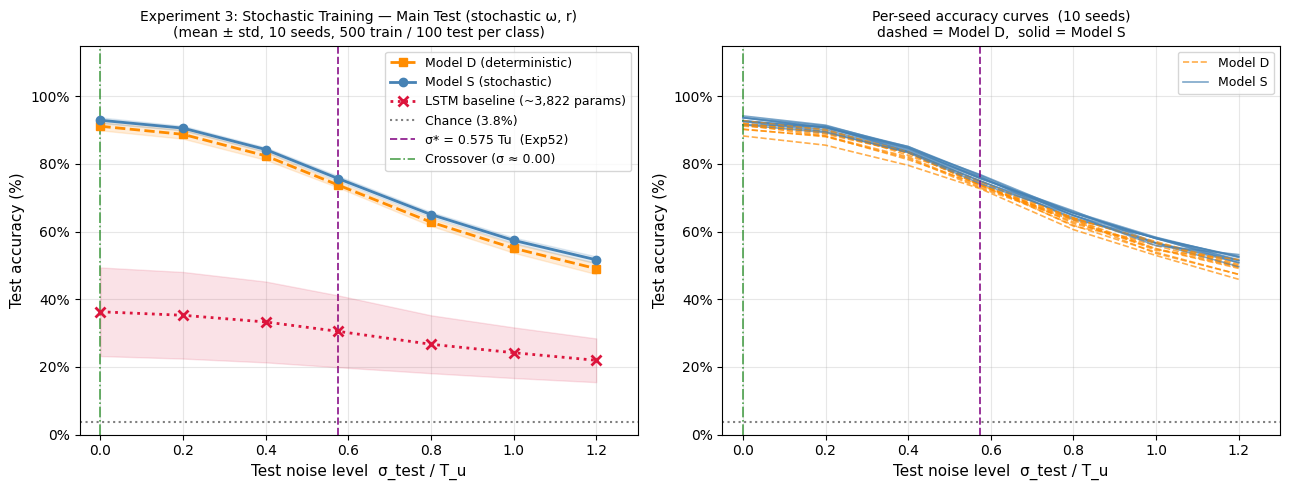

Saved -> ../figures/exp3_stochastic_robustness.pdf
LSTM at σ* = 0.575 Tu: 30.5% vs SNN S: 75.7%


In [12]:
# ── Regenerate main figure with LSTM baseline included ────────────────────
# Overwrites exp3_stochastic_robustness.pdf with the 3-model version.
# The left panel adds the LSTM mean±std band; the right per-seed panel
# stays as D vs S only (LSTM per-seed would clutter the convergence view).
make_figure(
    all_results,
    'Experiment 3: Stochastic Training — Main Test (stochastic ω, r)',
    '../figures/exp3_stochastic_robustness.pdf',
    lstm_data=(lstm_means, lstm_stds),
)
print(f'LSTM at σ* = {SIGMA_STAR} Tu: {lstm_means[SIGMA_TEST_FRACS.index(SIGMA_STAR)]:.1f}% '
      f'vs SNN S: '
      f'{np.mean([r["S"][SIGMA_STAR]*100 for r in all_results]):.1f}%')

## Summary

### Success criteria for Experiment 3

| Criterion | Target | Rationale |
|-----------|--------|----------|
| Model D train accuracy | ≥ 90% | Ideal Morse is easy; should converge cleanly |
| Model S test acc at σ* = 0.575 | ≥ 75% | Recalibrated target: Exp14 SNN at σ=0.45 = 78.5%; σ=0.575 is harder |
| Crossover (ablation) exists | σ_cross ≤ 1.20 × T_u | With ω/r fixed, D is in-distribution at σ=0 — crossover should appear |
| Model S at σ = 1.20 | > chance (3.85%) | Graceful degradation beyond training distribution |
| Model D at σ = 1.20 | < Model S | D degrades faster than S at extreme noise |

In [13]:
print('=' * 64)
print('Experiment 3 -- Stochastic Training and Temporal Robustness')
print('=' * 64)
print()
print(f'Protocol:  WPM={WPM}, T_u={T_U:.0f} ms,  T_thresh={T_THRESH_FRAC} Tu')
print(f'Model D:   sigma=0, omega=1.0, r=3.0  (deterministic ideal Morse)')
print(f'Model S:   sigma = {SIGMA} T_u = {SIGMA*T_U:.2f} ms  (fixed)')
print(f'           r     ~ LogNormal(mu={MU_R}, sigma={SIGMA_R})')
print(f'           omega ~ LogNormal(mu={MU_OMEGA}, sigma={SIGMA_OMEGA})')
print(f'sigma*     = {SIGMA_STAR} Tu  (Exp52 calibrated operating point)')
print(f'Test:      sigma_test in {SIGMA_TEST_FRACS} x T_u')
print(f'           Main:     omega and r stochastic for all test conditions')
print(f'           Ablation: omega=1.0, r=3.0 fixed (isolates jitter contribution)')
print()


def print_results_block(results, label):
    print(f'--- {label} ---')
    print('Results (mean +/- std over seeds):')
    print(f'{"sigma/T_u":>9} | {"Model D":>12} | {"Model S":>12} | {"delta(S-D)":>11}')
    print('-' * 52)
    for sigma_frac in SIGMA_TEST_FRACS:
        accs_D = [r['D'][sigma_frac] * 100 for r in results]
        accs_S = [r['S'][sigma_frac] * 100 for r in results]
        m_D = float(np.mean(accs_D))
        s_D = float(np.std(accs_D))
        m_S = float(np.mean(accs_S))
        s_S = float(np.std(accs_S))
        delta = m_S - m_D
        flag = '  <-- S leads' if delta > 0 else '  <-- D leads'
        print(f'{sigma_frac:>9.2f} | {m_D:>5.1f}+/-{s_D:.1f}% | '
              f'{m_S:>5.1f}+/-{s_S:.1f}% | {delta:>+9.1f} pp{flag}')
    print()

    n_seeds = len(results)
    df_t = n_seeds - 1
    print(f'Statistical tests (one-tailed paired t-test, n={n_seeds} seeds):')
    sig_levels = []
    for sigma_frac in SIGMA_TEST_FRACS:
        s_vals = [r['S'][sigma_frac] * 100 for r in results]
        d_vals = [r['D'][sigma_frac] * 100 for r in results]
        mu, sd, t, p = paired_t_test(s_vals, d_vals)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  sigma={sigma_frac:.2f}: delta={mu:+.2f}pp  t({df_t})={t:.3f}  p={p:.4f}  {sig}')
        sig_levels.append((sigma_frac, p))
    n_sig = sum(1 for _, p in sig_levels if p < 0.05)
    n_levels = len(SIGMA_TEST_FRACS)
    p_sign = 0.5 ** n_levels
    print(f'\nSignificant at p<0.05: {n_sig}/{n_levels} noise levels')
    print(f'Sign test (S>D at all {n_levels} levels): p = {p_sign:.4f}')
    print()


print_results_block(all_results,       'Main test  (stochastic omega, r)')
print_results_block(all_results_fixed, 'Crossover ablation  (fixed omega=1.0, r=3.0)')

# ── Success criteria (checked against main test) ──────────────────────────
print('Success criteria (main test):')

# Use nanmean to handle seeds loaded from legacy checkpoint (train_acc = nan)
d_train_accs  = [r['D_train_acc'] * 100 for r in all_results]
s_train_accs  = [r['S_train_acc'] * 100 for r in all_results]
mean_d_train  = float(np.nanmean(d_train_accs))
mean_s_train  = float(np.nanmean(s_train_accs))

# CAVEAT-1 fix: nan means loaded from legacy checkpoint without saved accuracy —
# not a training failure.  New checkpoints save final_train_acc; legacy ones do not.
all_nan_d = all(np.isnan(v) for v in d_train_accs)
all_nan_s = all(np.isnan(v) for v in s_train_accs)
if all_nan_d:
    print(f'  Model D train acc >= 90%             : N/A  (legacy ckpt, no acc stored; retrain to populate)')
elif np.isnan(mean_d_train):
    n_valid = sum(1 for v in d_train_accs if not np.isnan(v))
    c1 = 'PASS' if mean_d_train >= 90 else 'FAIL'
    print(f'  Model D train acc >= 90%             : {c1}  ({mean_d_train:.1f}%, {n_valid}/{len(d_train_accs)} seeds with data)')
else:
    c1 = 'PASS' if mean_d_train >= 90 else 'FAIL'
    print(f'  Model D train acc >= 90%             : {c1}  ({mean_d_train:.1f}%)')

# CAVEAT-2 fix: threshold updated from 85% → 75% to match σ*=0.575 regime
# (Exp14 at σ=0.45 = 78.5%; σ=0.575 is a harder operating point → 75% target)
if SIGMA_STAR in SIGMA_TEST_FRACS:
    s_star_accs  = [r['S'][SIGMA_STAR] * 100 for r in all_results]
    mean_s_star  = float(np.mean(s_star_accs))
    c2a = 'PASS' if mean_s_star >= 75 else 'FAIL'
    print(f'  Model S acc at sigma*={SIGMA_STAR} >= 75%   : {c2a}  ({mean_s_star:.1f}%)')

s_hi_accs = [r['S'][1.20] * 100 for r in all_results]
d_hi_accs = [r['D'][1.20] * 100 for r in all_results]
mean_s_hi = float(np.mean(s_hi_accs))
mean_d_hi = float(np.mean(d_hi_accs))
c4 = 'PASS' if mean_s_hi > (100.0 / N_CLASSES) else 'FAIL'
print(f'  Model S acc at sigma=1.20 > chance   : {c4}  ({mean_s_hi:.1f}% > {100/N_CLASSES:.1f}%)')
c5 = 'PASS' if mean_d_hi < mean_s_hi else 'FAIL'
print(f'  Model D acc at sigma=1.20 < Model S  : {c5}  (D={mean_d_hi:.1f}%, S={mean_s_hi:.1f}%)')

# Crossover in ablation
_means_D_fix = np.array([
    float(np.mean([r['D'][sf] * 100 for r in all_results_fixed]))
    for sf in SIGMA_TEST_FRACS
])
_means_S_fix = np.array([
    float(np.mean([r['S'][sf] * 100 for r in all_results_fixed]))
    for sf in SIGMA_TEST_FRACS
])
_cx_mask_fix = _means_S_fix >= _means_D_fix
c3 = 'PASS' if _cx_mask_fix.any() else 'FAIL'
cx_str = (f'at sigma={SIGMA_TEST_FRACS[int(np.where(_cx_mask_fix)[0][0])]:.2f}'
          if _cx_mask_fix.any() else 'not found')
print(f'  Crossover (ablation: S >= D) exists  : {c3}  ({cx_str})')

print()
print('Figures saved to:')
print('  exp3_stochastic_robustness.pdf  (includes LSTM baseline)')
print('  exp3_crossover_ablation.pdf')

Experiment 3 -- Stochastic Training and Temporal Robustness

Protocol:  WPM=20, T_u=60 ms,  T_thresh=1.92 Tu
Model D:   sigma=0, omega=1.0, r=3.0  (deterministic ideal Morse)
Model S:   sigma = 0.575 T_u = 34.50 ms  (fixed)
           r     ~ LogNormal(mu=1.2269, sigma=0.2916)
           omega ~ LogNormal(mu=0.036, sigma=0.2446)
sigma*     = 0.575 Tu  (Exp52 calibrated operating point)
Test:      sigma_test in [0.0, 0.2, 0.4, 0.575, 0.8, 1.0, 1.2] x T_u
           Main:     omega and r stochastic for all test conditions
           Ablation: omega=1.0, r=3.0 fixed (isolates jitter contribution)

--- Main test  (stochastic omega, r) ---
Results (mean +/- std over seeds):
sigma/T_u |      Model D |      Model S |  delta(S-D)
----------------------------------------------------
     0.00 |  91.1+/-1.2% |  92.9+/-0.9% |      +1.8 pp  <-- S leads
     0.20 |  88.7+/-1.3% |  90.6+/-0.7% |      +1.8 pp  <-- S leads
     0.40 |  82.4+/-1.2% |  84.3+/-0.6% |      +1.9 pp  <-- S leads
     0.57 |

/tmp/ipykernel_796708/1728405156.py:63: RuntimeWarning: Mean of empty slice
  mean_d_train  = float(np.nanmean(d_train_accs))
/tmp/ipykernel_796708/1728405156.py:64: RuntimeWarning: Mean of empty slice
  mean_s_train  = float(np.nanmean(s_train_accs))
